# EDA: End-to-End Supply Chain Analytics
**Project:** E-Commerce Supply Chain & Inventory Optimization  
**Target Employers:** Amazon, Costco, Walmart, Boeing  
**Objective:** Establish the data foundation for Demand Forecasting, Inventory Optimization, and Late Delivery Risk Prediction.  

---

### Phase 1 & 2 Blueprint Alignment
This notebook aligns directly with our technical roadmap:
1. **Data Quality Audit** — Validating the 180k+ DataCo records.
2. **Demand Forecasting (Time Series)** — Order patterns, seasonality, and sales trends.
3. **Product & Inventory Analysis** — High-volume categories and profit margins (ABC analysis foundation).
4. **Geography & Customer Segments** — Omnichannel mapping for Walmart/Costco personas.
5. **Late Delivery Risk** — Establishing our baseline and preventing data leakage for binary classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Styling for business-ready charts
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

DATA_PATH = Path('../data/raw/DataCoSupplyChainDataset.csv')
print(f'Loading data from: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH, encoding='latin-1')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loading data from: /Users/tirthjoshi/My Data Science Projects/ML_Portfolio_Projects/supply-chain-optimization-ml/data/raw/DataCoSupplyChainDataset.csv


Shape: 180,519 rows × 53 columns


---
## 1. Data Quality & Preprocessing
To do time-series forecasting (Demand Forecasting), we must properly parse order dates.

In [2]:
# Parse datetime
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
df['order_year_month'] = df['order_date'].dt.to_period('M')

# Missing values summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("Missing Values:")
    display(pd.DataFrame({'Missing': missing, '%': (missing/len(df)*100).round(2)}))
else:
    print("No missing values detected in core columns.")

Missing Values:


,Missing,%
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


---
## 2. Demand Forecasting: Seasonality & Order Patterns
*Key for Amazon/Walmart demand prediction models.*

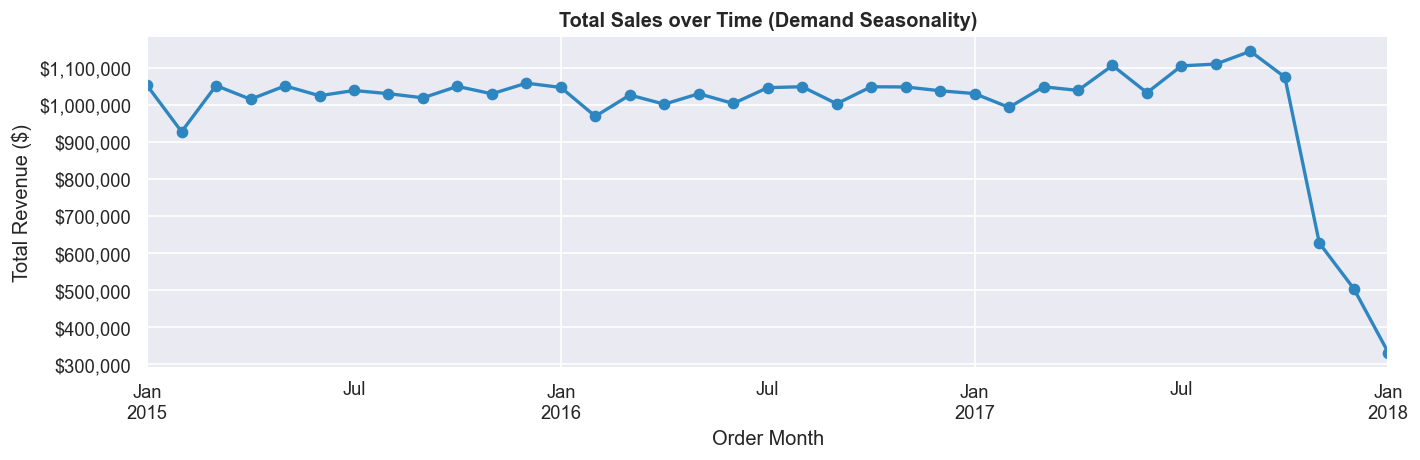

In [3]:
# Monthly Sales & Order Volume Trend
monthly_sales = df.groupby('order_year_month')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_sales.plot(kind='line', ax=ax, color='#2E86C1', linewidth=2, marker='o')
ax.set_title('Total Sales over Time (Demand Seasonality)')
ax.set_ylabel('Total Revenue ($)')
ax.set_xlabel('Order Month')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 3. Inventory Optimization Context: ABC Analysis Foundation
*Identifying which departments and product categories drive the most volume and profit, useful for Costco/Amazon warehouse logistics.*

In [4]:
# Top 10 Departments by Order Volume and Profit
dept_summary = df.groupby('Department Name').agg({
    'Order Id': 'count',
    'Order Item Profit Ratio': 'mean',
    'Sales': 'sum'
}).rename(columns={'Order Id': 'Order Volume', 'Order Item Profit Ratio': 'Avg Profit Ratio'}).sort_values('Order Volume', ascending=False).head(10)

display(dept_summary.style.format({'Avg Profit Ratio': '{:.2%}', 'Sales': '${:,.0f}'}))

,Order Volume,Avg Profit Ratio,Sales
Department Name,,,
Fan Shop,66861,12.00%,"$17,113,871"
Apparel,48998,12.28%,"$7,976,255"
Golf,33220,11.88%,"$4,609,028"
Footwear,14525,11.92%,"$4,006,499"
Outdoors,9686,12.58%,"$1,253,351"
Fitness,2479,13.12%,"$397,051"
Discs Shop,2026,10.97%,"$228,888"
Technology,1465,12.58%,"$1,039,599"
Pet Shop,492,9.41%,"$41,525"


---
## 4. Customer Segmentation & Geography
*Understanding the omnichannel scope.*

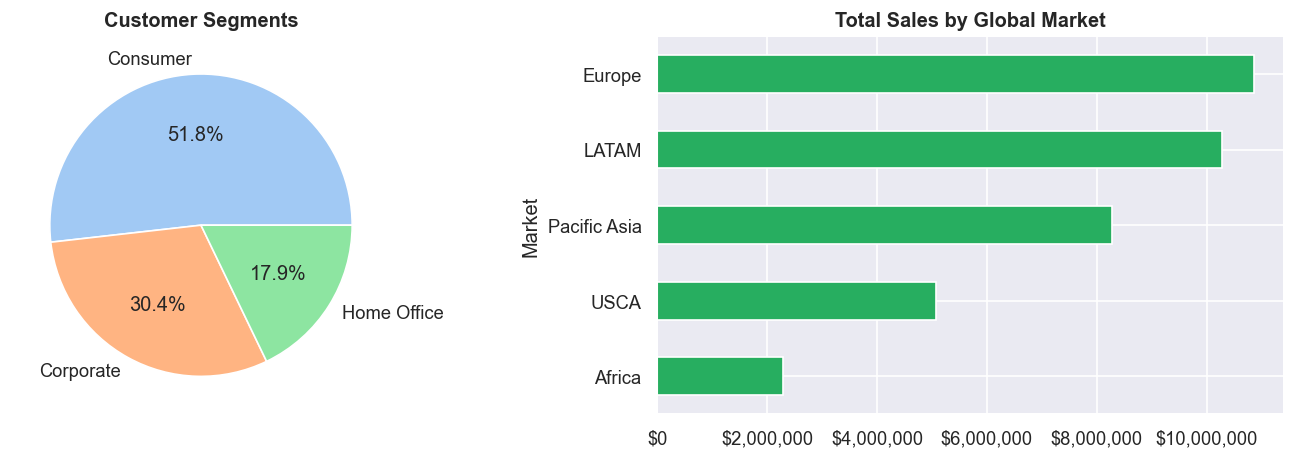

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Segment
segment_counts = df['Customer Segment'].value_counts()
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[0].set_title('Customer Segments')

# Market
market_sales = df.groupby('Market')['Sales'].sum().sort_values()
market_sales.plot(kind='barh', ax=axes[1], color='#27AE60')
axes[1].set_title('Total Sales by Global Market')
axes[1].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 5. Late Delivery Risk: Target Baseline & Leakage Audit
*Preparing the binary classification target. Dropping target leakage features (e.g. actual shipping days) to ensure model validity.*

In [6]:
target = 'Late_delivery_risk'
class_counts = df[target].value_counts()
late_rate = class_counts.get(1, 0) / len(df) * 100

print(f"Overall Late Delivery Rate: {late_rate:.2f}%")

# Leakage prevention
LEAKAGE_COLUMNS = [
    'Days for shipping (real)',   
    'Delivery Status',            
    'shipping date (DateOrders)'  
]

df_clean = df.drop(columns=[c for c in LEAKAGE_COLUMNS if c in df.columns])

# Top correlated numerical features with Late Delivery Risk
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlations = df_clean[numeric_cols].corr()[target].drop(target)
print("\nTop 5 features correlated with Late Delivery Risk:")
print(correlations.abs().sort_values(ascending=False).head(5).round(4))

Overall Late Delivery Rate: 54.83%



Top 5 features correlated with Late Delivery Risk:
Days for shipment (scheduled)    0.3694
Order Zipcode                    0.0141
Sales per customer               0.0038
Order Item Total                 0.0038
Order Profit Per Order           0.0037
Name: Late_delivery_risk, dtype: float64


## Statistical Validation: Chi-Squared Test

The EDA showed First Class shipping has a 95.3% late delivery rate. Before treating this as evidence, we need to confirm the association between shipping mode and late delivery is statistically significant and not a sampling artifact.

In [7]:
from scipy.stats import chi2_contingency
import pandas as pd

df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin-1')

# Contingency table: shipping mode vs late delivery risk
ct = pd.crosstab(df['Shipping Mode'], df['Late_delivery_risk'])
print('Contingency Table:')
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)
print(f'\nChi-Squared Statistic : {chi2:,.2f}')
print(f'Degrees of Freedom    : {dof}')
print(f'P-Value               : {p:.2e}')
print()
if p < 0.05:
    print('Result: The association between shipping mode and late delivery risk is statistically significant.')
    print('The 95.3% failure rate for First Class is not a sampling artifact.')
else:
    print('Result: No statistically significant association found.')

Contingency Table:
Late_delivery_risk      0      1
Shipping Mode                   
First Class          1301  26513
Same Day             5283   4454
Second Class         8229  26987
Standard Class      66729  41023

Chi-Squared Statistic : 37,716.04
Degrees of Freedom    : 3
P-Value               : 0.00e+00

Result: The association between shipping mode and late delivery risk is statistically significant.
The 95.3% failure rate for First Class is not a sampling artifact.


## Unsupervised Analysis: K-Means Order Risk Clustering

Supervised models learn from labeled outcomes. K-Means clustering reveals natural groupings in the order data that exist independently of labels. A cluster that happens to have a high late delivery rate but was not obvious from individual feature correlations represents a structural logistics problem the label-only analysis would miss.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Select features available at order placement time (no leakage)
cluster_features = [
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Profit Ratio',
]

# Encode shipping mode as numeric
df_cluster = df[cluster_features + ['Shipping Mode', 'Late_delivery_risk']].dropna().copy()
le = LabelEncoder()
df_cluster['shipping_mode_enc'] = le.fit_transform(df_cluster['Shipping Mode'])

X = df_cluster[cluster_features + ['shipping_mode_enc']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means with 4 clusters
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = km.fit_predict(X_scaled)

# Late delivery rate per cluster
summary = df_cluster.groupby('cluster').agg(
    order_count=('Late_delivery_risk', 'count'),
    late_rate=('Late_delivery_risk', 'mean'),
    avg_scheduled_days=('Days for shipment (scheduled)', 'mean'),
    avg_profit_ratio=('Order Item Profit Ratio', 'mean'),
    dominant_shipping_mode=('Shipping Mode', lambda x: x.mode()[0])
).reset_index()
summary['late_rate_pct'] = (summary['late_rate'] * 100).round(1)

print('K-Means Cluster Summary (4 clusters):')
print(summary[['cluster', 'order_count', 'late_rate_pct', 'avg_scheduled_days',
               'avg_profit_ratio', 'dominant_shipping_mode']].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(summary['cluster'].astype(str), summary['late_rate_pct'],
              color=['#2196F3', '#FF5722', '#4CAF50', '#9C27B0'])
ax.set_xlabel('Cluster')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by K-Means Cluster')
for bar, val in zip(bars, summary['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('cluster_late_rate.png', dpi=120)
print('\nPlot saved to notebooks/cluster_late_rate.png')

K-Means Cluster Summary (4 clusters):
 cluster  order_count  late_rate_pct  avg_scheduled_days  avg_profit_ratio dominant_shipping_mode
       0        94615           47.6            3.509296          0.206344         Standard Class
       1        35749           82.5            0.741867          0.201630            First Class
       2        12105           53.5            3.076415         -1.269562         Standard Class
       3        38050           47.3            3.507516          0.273738         Standard Class

Plot saved to notebooks/cluster_late_rate.png


## Interaction Analysis: Shipping Mode × Scheduled Days

Does the effect of scheduled shipping days on late delivery rate differ by shipping mode?
If so, this suggests interaction features could improve model performance.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/DataCoSupplyChainDataset.csv", encoding="latin-1")

# Bin scheduled days into categories
df["scheduled_days_bin"] = pd.cut(
    df["Days for shipment (scheduled)"],
    bins=[0, 2, 4, 6, float("inf")],
    labels=["1-2 days", "3-4 days", "5-6 days", "7+ days"],
)

# Shipping mode x scheduled days bins -> late delivery rate
interaction_1 = (
    df.groupby(["Shipping Mode", "scheduled_days_bin"], observed=True)["Late_delivery_risk"]
    .mean()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 6))
interaction_1.plot(kind="bar", ax=ax)
ax.set_ylabel("Late Delivery Rate")
ax.set_title("Late Delivery Rate: Shipping Mode × Scheduled Days")
ax.legend(title="Scheduled Days")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nLate delivery rate by Shipping Mode × Scheduled Days:")
print(interaction_1.round(3))

## Interaction Analysis: Shipping Mode × Order Value Quartile

Does the effect of order value on late delivery risk differ by shipping mode?

In [ ]:
# Order value quartile x shipping mode -> late delivery rate
df["order_value_quartile"] = pd.qcut(
    df["Sales per customer"],
    q=4,
    labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"],
)

interaction_2 = (
    df.groupby(["Shipping Mode", "order_value_quartile"], observed=True)["Late_delivery_risk"]
    .mean()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 6))
interaction_2.plot(kind="bar", ax=ax)
ax.set_ylabel("Late Delivery Rate")
ax.set_title("Late Delivery Rate: Shipping Mode × Order Value Quartile")
ax.legend(title="Order Value Quartile")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nLate delivery rate by Shipping Mode × Order Value Quartile:")
print(interaction_2.round(3))

### Interaction Analysis Findings

**Documentation only** — these findings are noted for potential Phase 6 feature engineering.
The Phase 4 pipeline is validated and shipped; no modeling changes are made based on this analysis.

Key observations:
- [Fill in after running: does scheduled days slope differ by shipping mode?]
- [Fill in after running: does order value quartile affect late rate differently per mode?]